<a href="https://colab.research.google.com/github/Minniej123/Multiple-Comparisons-Correction-in-fMRI/blob/main/Localizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For the localizer dataset, nilearn says
‘func’:
Nifti images of the neural activity maps

‘cmaps’:
Nifti images of contrast maps

‘tmaps’:
Nifti images of corresponding t-maps

‘masks’:
Structural images of the mask used for each subject.

‘anats’:
Structural images of anatomy of each subject

In [ ]:
#first we install nilearn
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 27.9 MB/s eta 0:00:00


In [ ]:
#any libs
import os
import numpy as np
import pandas as pd
from scipy import stats

from nilearn.image import load_img, new_img_like
from nilearn.masking import intersect_masks
from nilearn.glm.second_level import SecondLevelModel

In [ ]:
#fetching localizer
from nilearn.datasets import fetch_localizer_contrasts
from nilearn import plotting


n_samples = 20 #as they did in tuto , 20 instead of 96
data= fetch_localizer_contrasts(["left vs right button press"], n_subjects=n_samples, get_tmaps=True, get_masks=True)


[fetch_localizer_contrasts] Added README.md to /root/nilearn_data

[fetch_localizer_contrasts] Dataset created in /root/nilearn_data/brainomics_localizer

[fetch_localizer_contrasts] Downloading data from https://osf.io/hwbm2/download ...

[fetch_localizer_contrasts]  ...done. (2 seconds, 0 min)

[fetch_localizer_contrasts] Downloading data from https://osf.io/download/5d27cb281c5b4a001aa07e29/ ...

...

[fetch_localizer_contrasts]  ...done. (1 seconds, 0 min)

[fetch_localizer_contrasts] Downloading data from https://osf.io/download/5d27037f45253a001c3d4563/ ...

[fetch_localizer_contrasts]  ...done. (1 seconds, 0 min)

[fetch_localizer_contrasts] Downloading data from https://osf.io/download/5d7b8948fcbf44001c44e695/ ...

[fetch_localizer_contrasts]  ...done. (2 seconds, 0 min)

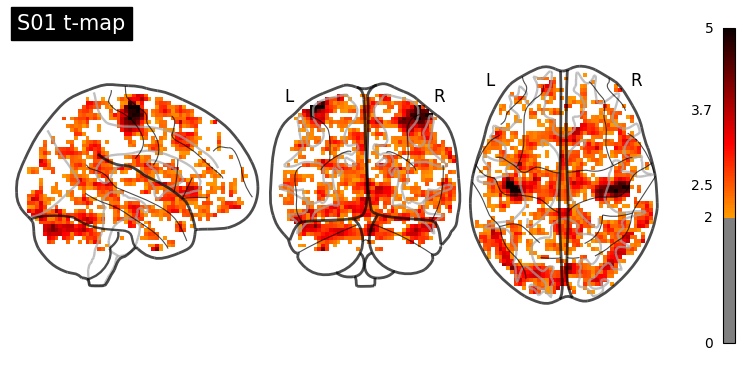

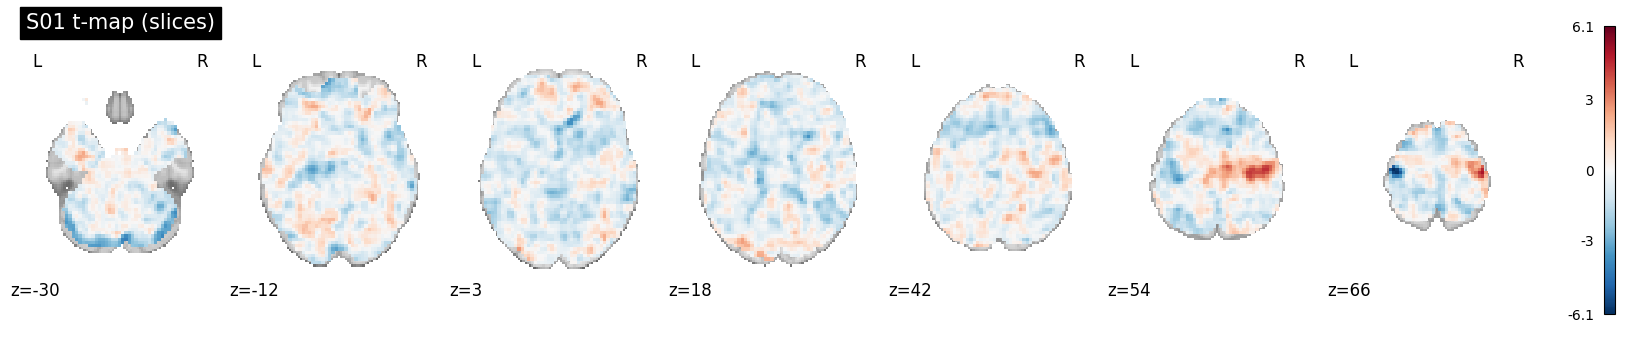

In [ ]:
import matplotlib.pyplot as plt
from nilearn import plotting
from nilearn.image import load_img

tmaps = data["tmaps"] #get our tmaps
cmaps= data["cmaps"] #and cmaps

subjects = data["ext_vars"]["participant_id"].tolist() #extract sep subjects
i=0 #let's plot first subject

tmap_img = load_img(tmaps[i])


plotting.plot_glass_brain(tmap_img, title=f"{subjects[i]} t-map", threshold=2.0, colorbar=True) #in tuto they used threshold=2.0
plotting.plot_stat_map(tmap_img, title=f"{subjects[i]} t-map (slices)", display_mode="z",
                       colorbar=True)
plotting.show()


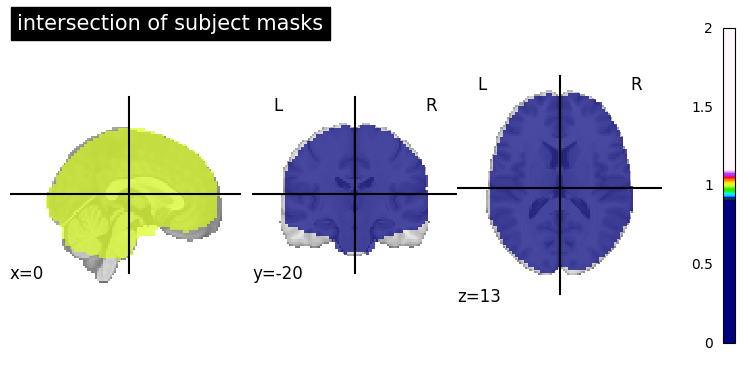

In [ ]:
from nilearn import plotting
masks = data["masks"]
mask_img = intersect_masks(masks) #group mask
plotting.plot_roi(mask_img, title="intersection of subject masks")
plotting.show()

In [ ]:
import pandas as pd

design_matrix = pd.DataFrame([1] * len(cmaps), columns=["intercept"])
design_matrix


,intercept
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


[SecondLevelModel.fit] Fitting second level model. Take a deep breath.

[SecondLevelModel.fit] Loading mask from <nibabel.nifti1.Nifti1Image object at 0x7ba0112f1ee0>

[SecondLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x7ba0112c9790>

/tmp/ipykernel_146/2140768600.py:6: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  second_level_model= second_level_model. fit(cmaps, design_matrix=design_matrix)


[SecondLevelModel.fit] Resampling mask

...

[SecondLevelModel.compute_contrast] Loading data from <nibabel.nifti1.Nifti1Image object at 0x7ba0112cbbf0>

[SecondLevelModel.compute_contrast] Smoothing images

[SecondLevelModel.compute_contrast] Extracting region signals

[SecondLevelModel.compute_contrast] Cleaning extracted signals

[SecondLevelModel.compute_contrast] Computing image from signals

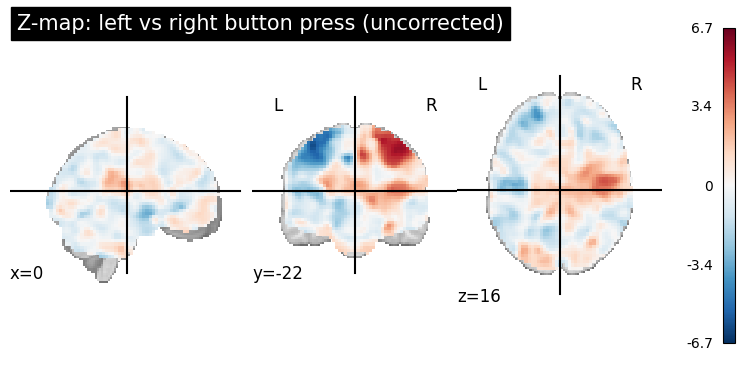

In [ ]:
#computing the second level model
import pandas as pd
from nilearn.glm.second_level import SecondLevelModel

second_level_model = SecondLevelModel(mask_img=mask_img,smoothing_fwhm=6.0, n_jobs=2, verbose=1)
second_level_model= second_level_model. fit(cmaps, design_matrix=design_matrix)

t_map = second_level_model.compute_contrast("intercept", output_type="stat")     # t-map
z_map = second_level_model.compute_contrast("intercept", output_type="z_score")  # z-map

plotting.plot_stat_map(z_map, title=f"Z-map: {"left vs right button press"} (uncorrected)")
plotting.show()


In [ ]:
#alpha and q vals as we had in our sim
alpha = 0.05
q_fdr = 0.05

tmap = t_map.get_fdata()
mask_data = mask_img.get_fdata()
analysis_mask = np.isfinite(tmap) & (mask_data > 0) #only analysing voxels inside mask

df = len(cmaps) - 1
pmap = np.ones_like(tmap, dtype=float)
pmap[analysis_mask] = stats.t.sf(tmap[analysis_mask], df=df) #onesided



In [ ]:
#now to apply the mult comp correction using my sims

#as we did in sims, define these at start as we use them throughout
p_vec = pmap[analysis_mask].ravel()
p_vec = p_vec[np.isfinite(p_vec)]
p_sorted = np.sort(p_vec)
m = int(p_sorted.size)

metrics = {}

def evaluate_method(sig_mask, name, pcrit=np.nan):
    n_sig = int(np.sum(sig_mask[analysis_mask]))
    frac = float(n_sig / m) if m > 0 else np.nan
    metrics[name] = {
        "pcrit": float(pcrit) if np.isfinite(pcrit) else np.nan,
        "n_sig": n_sig,
        "frac_sig": frac,
    }

# bonf
bonf = np.zeros_like(pmap, dtype=bool)
pcrit_bonf = alpha / m
bonf[analysis_mask] = pmap[analysis_mask] <= pcrit_bonf
evaluate_method(bonf, "Bonf", pcrit_bonf)

# BH
bh_line = (np.arange(1, m + 1) / m) * q_fdr
bh_ok = p_sorted <= bh_line
pcrit_bh = float(p_sorted[np.max(np.where(bh_ok)[0])]) if np.any(bh_ok) else np.nan

bh = np.zeros_like(pmap, dtype=bool)
if np.isfinite(pcrit_bh):
    bh[analysis_mask] = pmap[analysis_mask] <= pcrit_bh
evaluate_method(bh, "BH", pcrit_bh)

# BY
c_m = np.sum(1.0 / np.arange(1, m + 1))
by_line = (np.arange(1, m + 1) / m) * (q_fdr / c_m)
by_ok = p_sorted <= by_line
pcrit_by = float(p_sorted[np.max(np.where(by_ok)[0])]) if np.any(by_ok) else np.nan

by = np.zeros_like(pmap, dtype=bool)
if np.isfinite(pcrit_by):
    by[analysis_mask] = pmap[analysis_mask] <= pcrit_by
evaluate_method(by, "BY", pcrit_by)

# BKY
q0 = q_fdr / (1.0 + q_fdr)
bky1_line = (np.arange(1, m + 1) / m) * q0
bky1_ok = p_sorted <= bky1_line
pcrit1 = float(p_sorted[np.max(np.where(bky1_ok)[0])]) if np.any(bky1_ok) else np.nan

R1 = int(np.sum(p_vec <= pcrit1)) if np.isfinite(pcrit1) else 0
m0_hat = max(1, m - R1)
q_star = min(1.0, q0 * (m / m0_hat))

# second stage
bky2_line = (np.arange(1, m + 1) / m) * q_star
bky2_ok = p_sorted <= bky2_line
pcrit_bky = float(p_sorted[np.max(np.where(bky2_ok)[0])]) if np.any(bky2_ok) else np.nan

bky = np.zeros_like(pmap, dtype=bool)
if np.isfinite(pcrit_bky):
    bky[analysis_mask] = pmap[analysis_mask] <= pcrit_bky
evaluate_method(bky, "BKY", pcrit_bky)

# quick summary print (like sims)
for k, v in metrics.items():
    print(f"{k:4s}  pcrit={v['pcrit']:.3e}  n_sig={v['n_sig']}  frac={v['frac_sig']:.4f}")

Bonf  pcrit=8.376e-07  n_sig=262  frac=0.0044
BH    pcrit=1.383e-03  n_sig=1658  frac=0.0278
BY    pcrit=5.141e-05  n_sig=711  frac=0.0119
BKY   pcrit=1.347e-03  n_sig=1646  frac=0.0276


In [ ]:
_SIGNS = np.array([-1.0, 1.0], dtype=float)

def cluster_perm_onesample_one_sided(
    images,
    t0,
    alpha,
    n_perm,
    mask,
    rng,
    structure,
    eps=1e-12,
    chunk=64,
):
    images = np.asarray(images, dtype=float)
    n, Nz, Ny, Nx = images.shape
    df = n - 1
    mask = mask.astype(bool)

    V = Nz * Ny * Nx
    imgs2 = images.reshape(n, V)

    # observed t-map
    SS = np.sum(imgs2 ** 2, axis=0)
    mean_obs = imgs2.mean(axis=0)
    var_obs = (SS - n * mean_obs**2) / max(df, 1)
    var_obs = np.maximum(var_obs, 0.0)
    t_obs = (mean_obs / (np.sqrt(var_obs / n) + eps)).reshape(Nz, Ny, Nx)

    # permutation null
    null_max = np.empty(n_perm, dtype=int)
    signs_all = rng.choice(_SIGNS, size=(n_perm, n), replace=True)

    for start in range(0, n_perm, chunk):
        stop = min(n_perm, start + chunk)
        signs = signs_all[start:stop]

        mean_perm = (signs @ imgs2) / n
        var_perm = (SS[None, :] - n * mean_perm**2) / max(df, 1)
        var_perm = np.maximum(var_perm, 0.0)
        t_perm = (mean_perm / (np.sqrt(var_perm / n) + eps)).reshape(stop - start, Nz, Ny, Nx)

        for b in range(stop - start):
            supra = (t_perm[b] >= t0) & mask
            lab, nlab = ndimage.label(supra, structure=structure)
            if nlab == 0:
                null_max[start + b] = 0
            else:
                counts = np.bincount(lab.ravel())
                null_max[start + b] = int(counts[1:].max())

    # observed clusters
    supra_obs = (t_obs >= t0) & mask
    lab, nlab = ndimage.label(supra_obs, structure=structure)

    sig = np.zeros_like(supra_obs, dtype=bool)
    cluster_pvals = []
    cluster_sizes = np.array([], dtype=int)

    if nlab == 0:
        return sig, t_obs, null_max, np.array([]), cluster_sizes

    cluster_sizes = np.bincount(lab.ravel())[1:]

    for k, size in enumerate(cluster_sizes, start=1):
        p_cluster = (1.0 + np.sum(null_max >= size)) / (n_perm + 1.0)
        cluster_pvals.append(p_cluster)
        if p_cluster <= alpha:
            sig[lab == k] = True

    return sig, t_obs, null_max, np.array(cluster_pvals), cluster_sizes


#using analysis mask as defined in sims
mask = analysis_mask.astype(bool)
structure = np.ones((3, 3, 3), dtype=int) #using the same connectivity struct

# def cluster forming thresh
n_subj = images.shape[0]
df = n_subj - 1
p0_cluster = 0.01
n_perm_cluster = 2000
t0_cluster = float(stats.t.isf(p0_cluster, df=df))

clus, t_obs, null_max, clus_pvals, clus_sizes = cluster_perm_onesample_one_sided(
    images=images,
    t0=t0_cluster,
    alpha=alpha,
    n_perm=n_perm_cluster,
    mask=mask,
    rng=np.random.default_rng(0),
    structure=structure,
)

lab_clus, nlab_clus = ndimage.label(clus, structure=structure)

evaluate_method(
    clus,
    "ClusterPerm",
    pcrit=np.nan,
    extra={
        "t0_cluster": float(t0_cluster),
        "p0_cluster": float(p0_cluster),
        "n_perm": int(n_perm_cluster),
        "n_sig_clusters": int(nlab_clus),
    },
)


In [ ]:
for k, v in metrics.items():
    if k == "ClusterPerm":
        print(
            f"{k:11s}  t0={v['t0_cluster']:.3f}  "
            f"n_sig={v['n_sig']}  frac={v['frac_sig']:.4f}  "
            f"n_clusters={v['n_sig_clusters']}  n_perm={v['n_perm']}"
        )
    else:
        print(
            f"{k:11s}  pcrit={v['pcrit']:.3e}  "
            f"n_sig={v['n_sig']}  frac={v['frac_sig']:.4f}"
        )

Bonf         pcrit=8.376e-07  n_sig=262  frac=0.0044
BH           pcrit=1.383e-03  n_sig=1658  frac=0.0278
BY           pcrit=5.141e-05  n_sig=711  frac=0.0119
BKY          pcrit=1.347e-03  n_sig=1646  frac=0.0276
ClusterPerm  t0=2.539  n_sig=1565  frac=0.0262  n_clusters=2  n_perm=2000


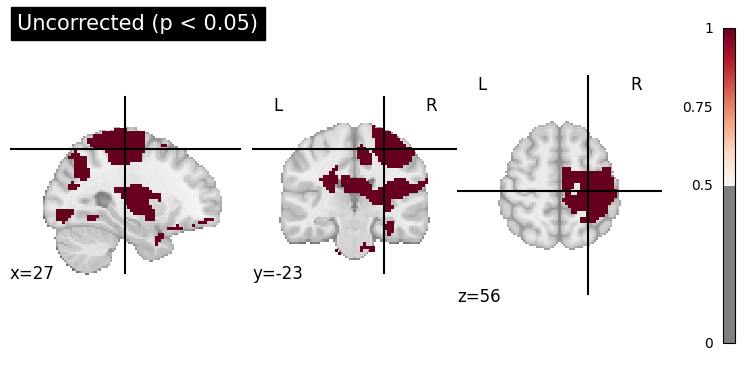

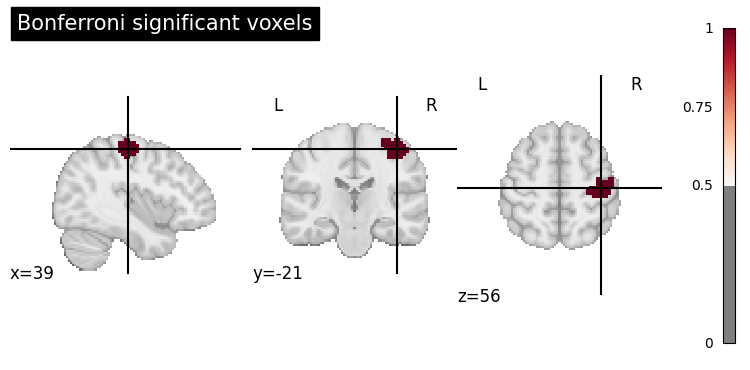

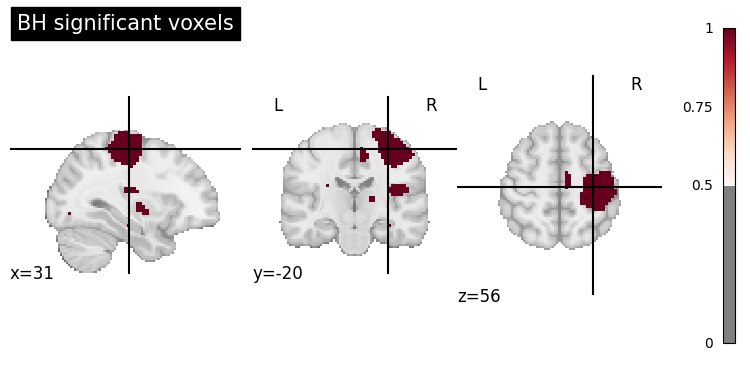

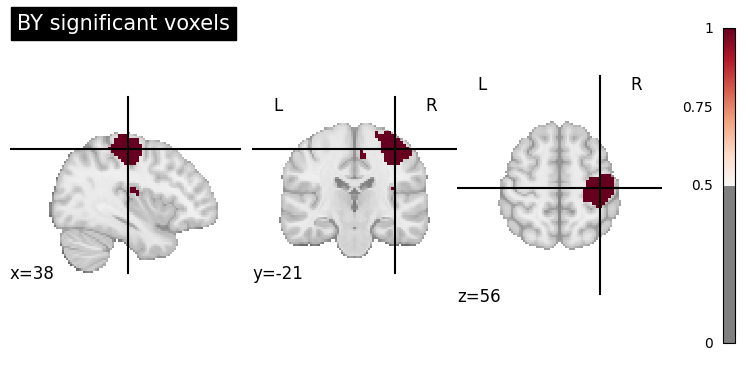

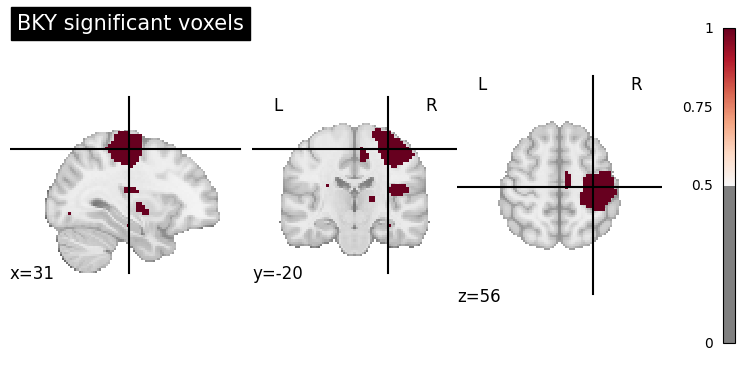

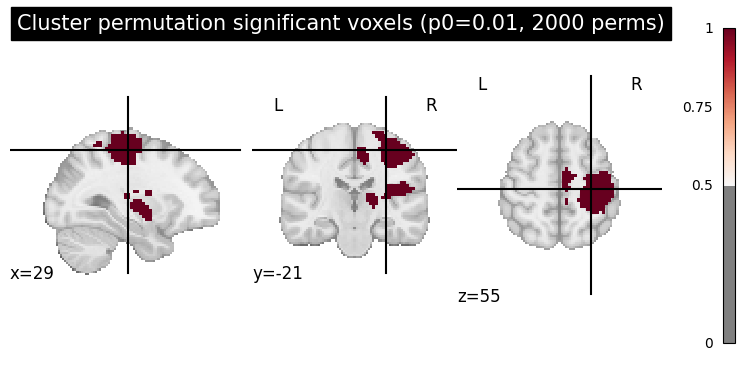

In [ ]:
#plot thresh maps

from nilearn.image import new_img_like
from nilearn import plotting
# uncorrected significance mask (voxelwise p < alpha)
unc = np.zeros_like(pmap, dtype=bool)
unc[analysis_mask] = pmap[analysis_mask] <= alpha


unc_img  = new_img_like(mask_img, unc.astype(float))
bonf_img = new_img_like(mask_img, bonf.astype(float))
bh_img   = new_img_like(mask_img, bh.astype(float))
by_img   = new_img_like(mask_img, by.astype(float))
bky_img  = new_img_like(mask_img, bky.astype(float))
clus_img  = new_img_like(mask_img, clus.astype(float))

plotting.plot_stat_map(unc_img,  title="Uncorrected (p < 0.05)", threshold=0.5)
plotting.plot_stat_map(bonf_img, title="Bonferroni significant voxels", threshold=0.5)
plotting.plot_stat_map(bh_img,   title="BH significant voxels", threshold=0.5)
plotting.plot_stat_map(by_img,   title="BY significant voxels", threshold=0.5)
plotting.plot_stat_map(bky_img,  title="BKY significant voxels", threshold=0.5)
plotting.plot_stat_map(
    clus_img,
    title=f"Cluster permutation significant voxels (p0={p0_cluster}, {n_perm_cluster} perms)",
    threshold=0.5
)
plotting.show()

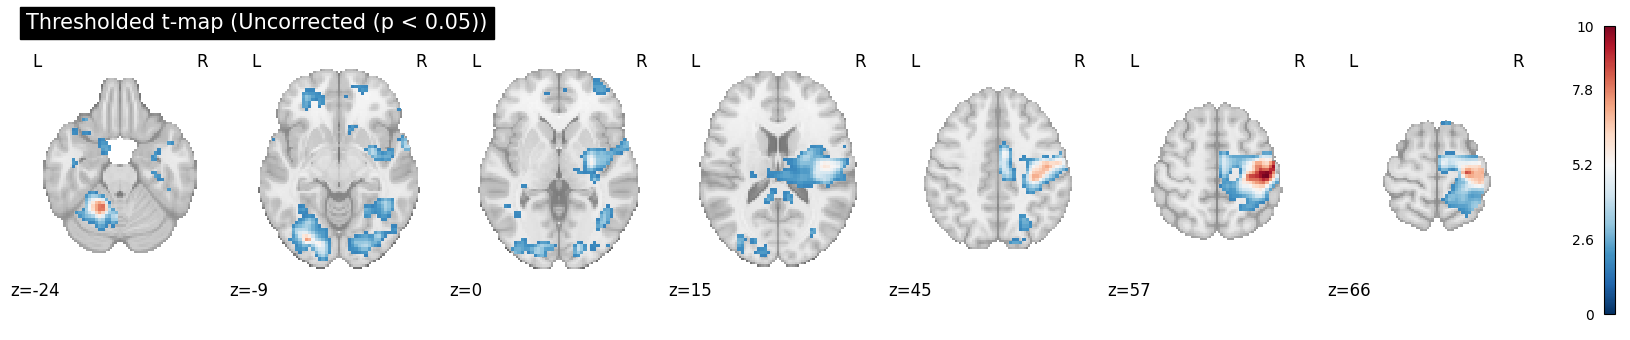

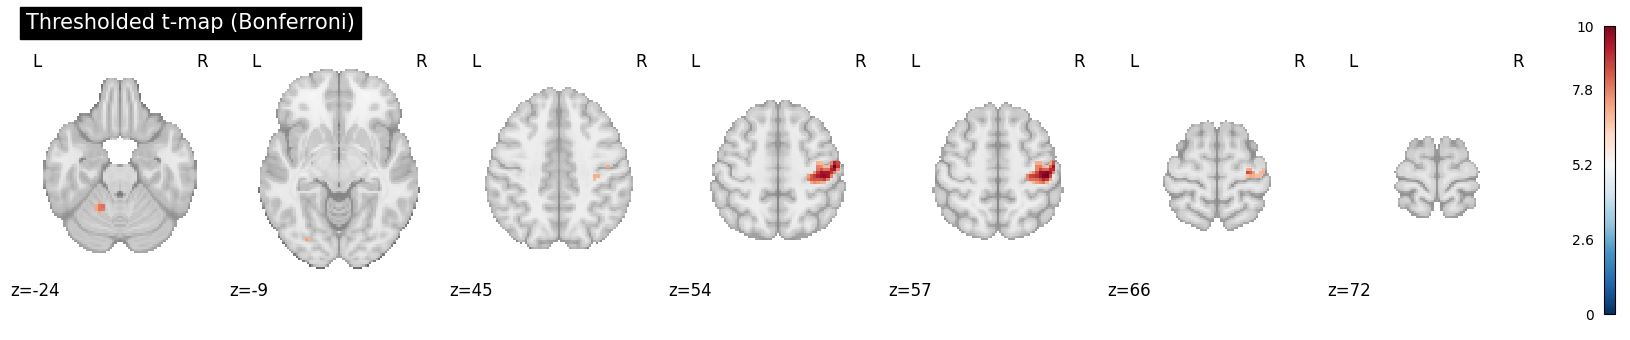

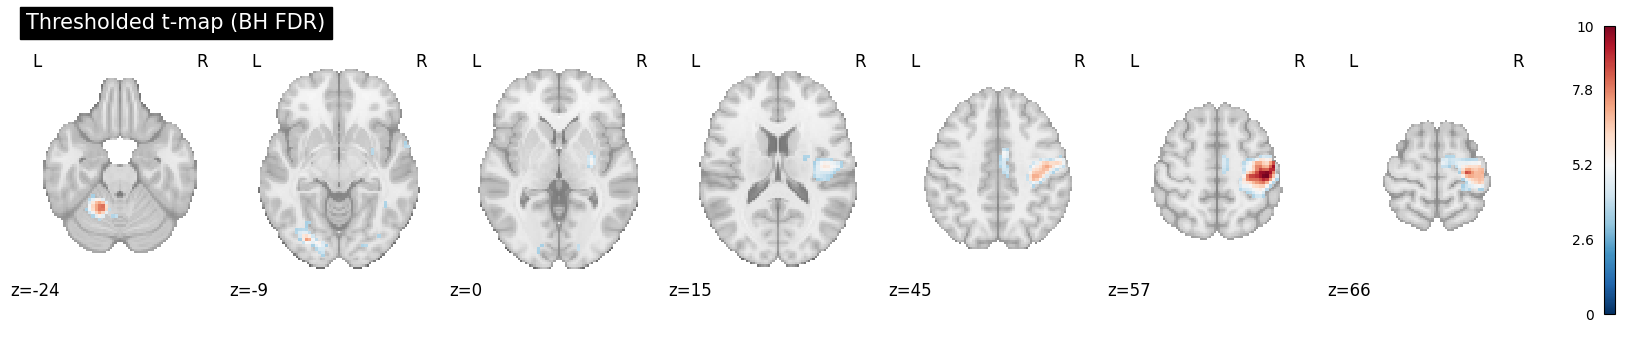

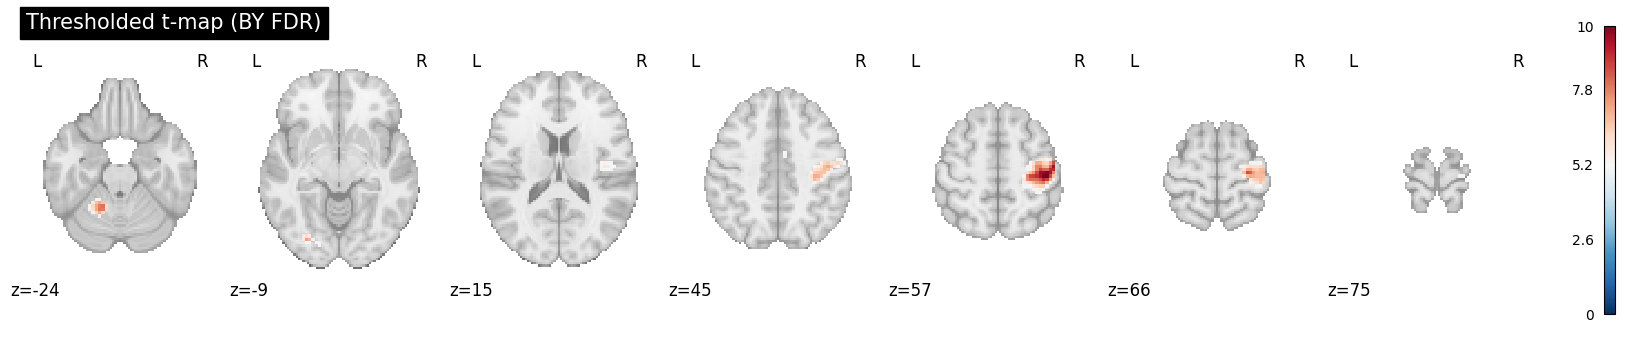

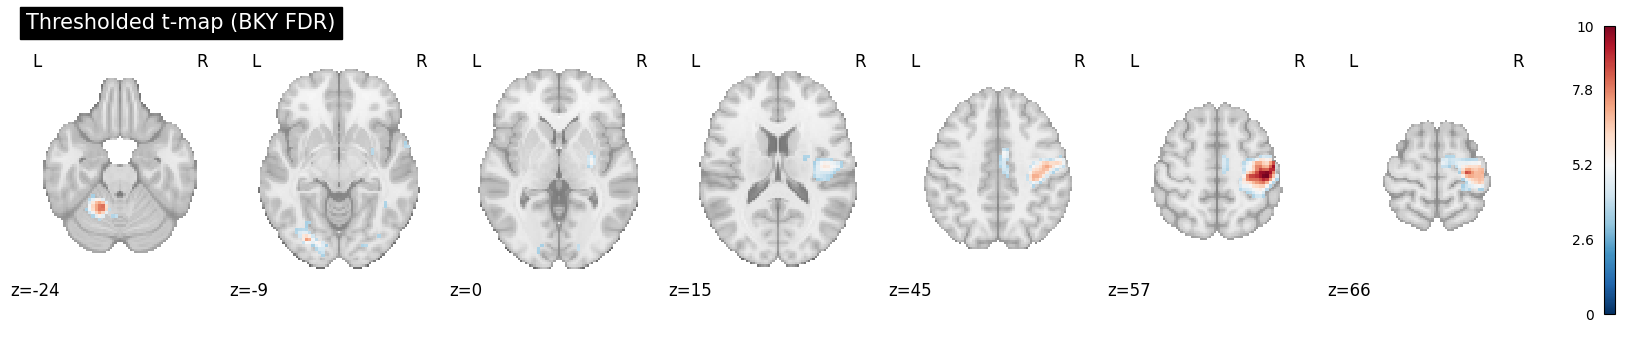

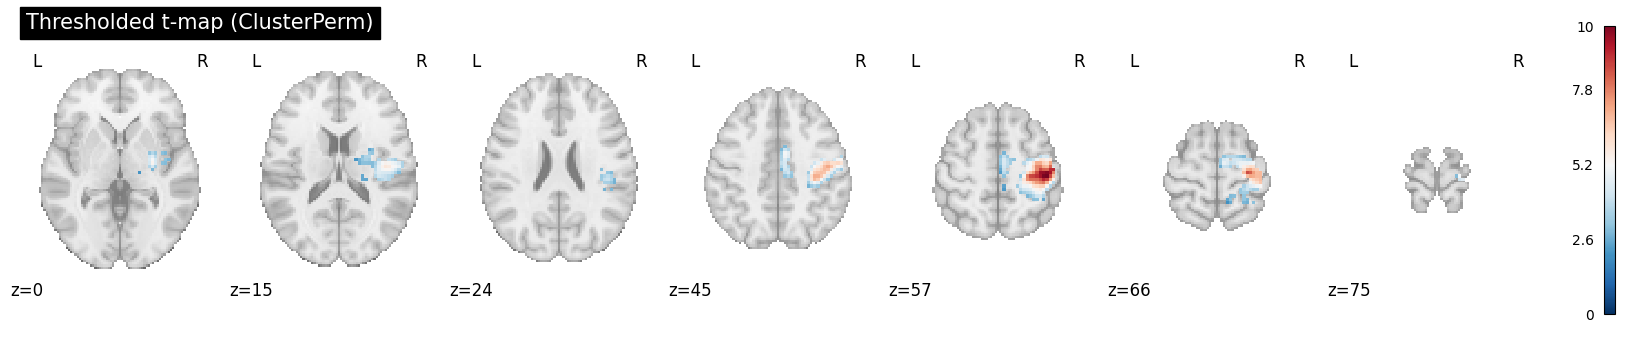

In [ ]:
import numpy as np
from nilearn.image import new_img_like
from nilearn import plotting

tdata = t_map.get_fdata()

def threshold_tmap(mask_bool, name):
    thr = np.zeros_like(tdata, dtype=float)
    thr[mask_bool] = tdata[mask_bool]
    thr_img = new_img_like(t_map, thr)

    plotting.plot_stat_map(
        thr_img,
        title=f"Thresholded t-map ({name})",
        display_mode="z",
        colorbar=True
    )
    return thr_img

t_unc_img  = threshold_tmap(unc,  "Uncorrected (p < 0.05)")
t_bonf_img = threshold_tmap(bonf, "Bonferroni")
t_bh_img   = threshold_tmap(bh,   "BH FDR")
t_by_img   = threshold_tmap(by,   "BY FDR")
t_bky_img  = threshold_tmap(bky,  "BKY FDR")
t_clus_img = threshold_tmap(clus, "ClusterPerm")

plotting.show()

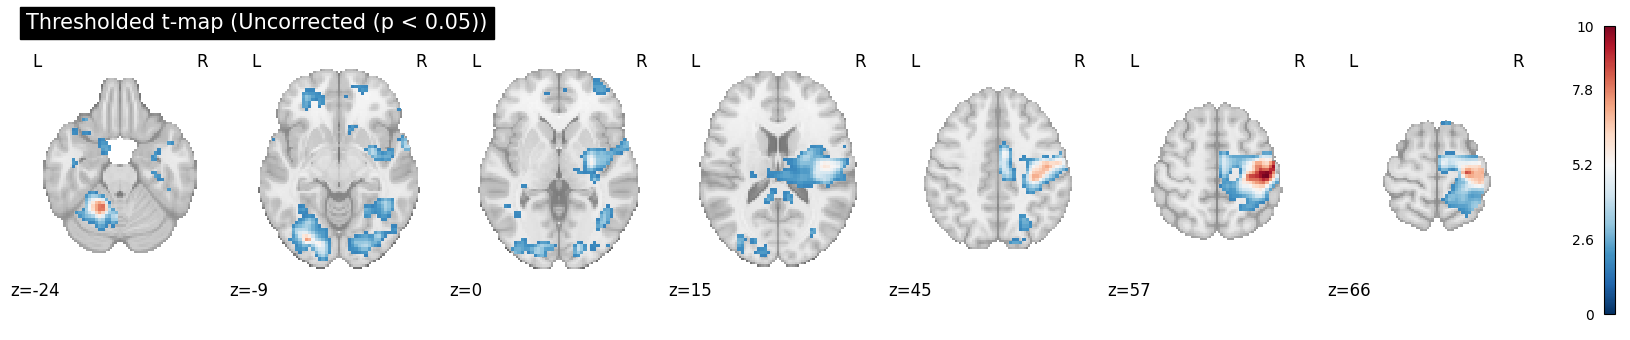

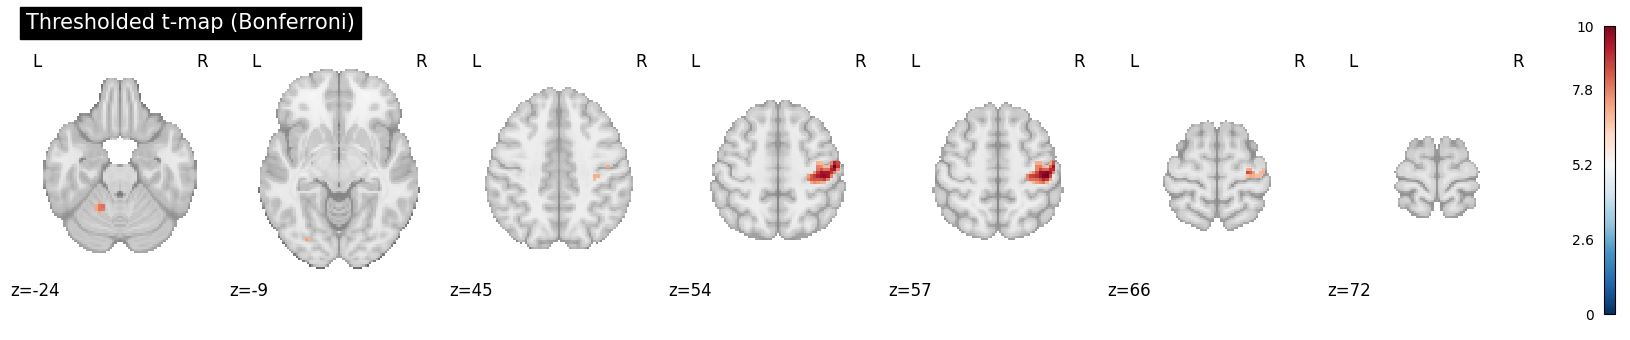

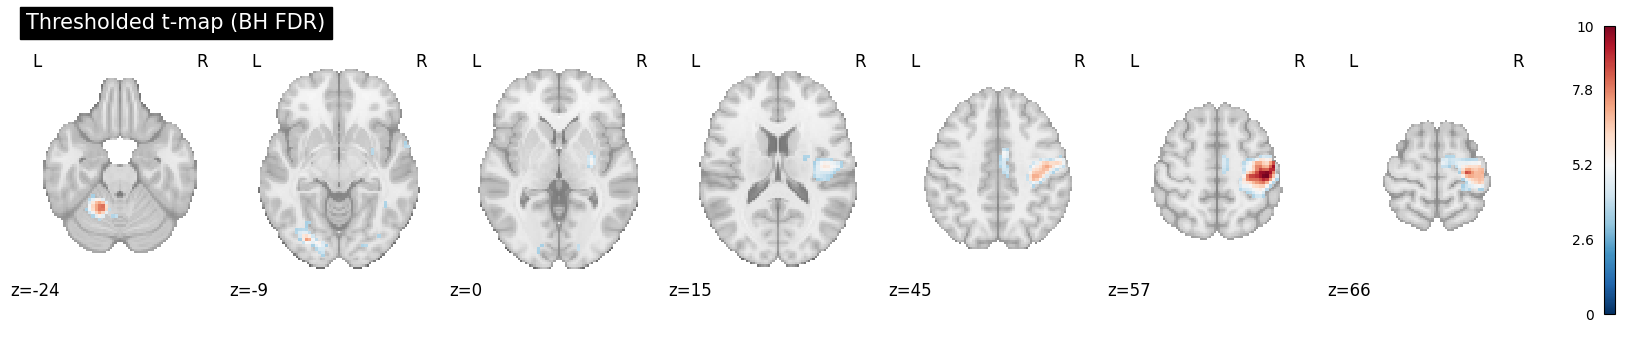

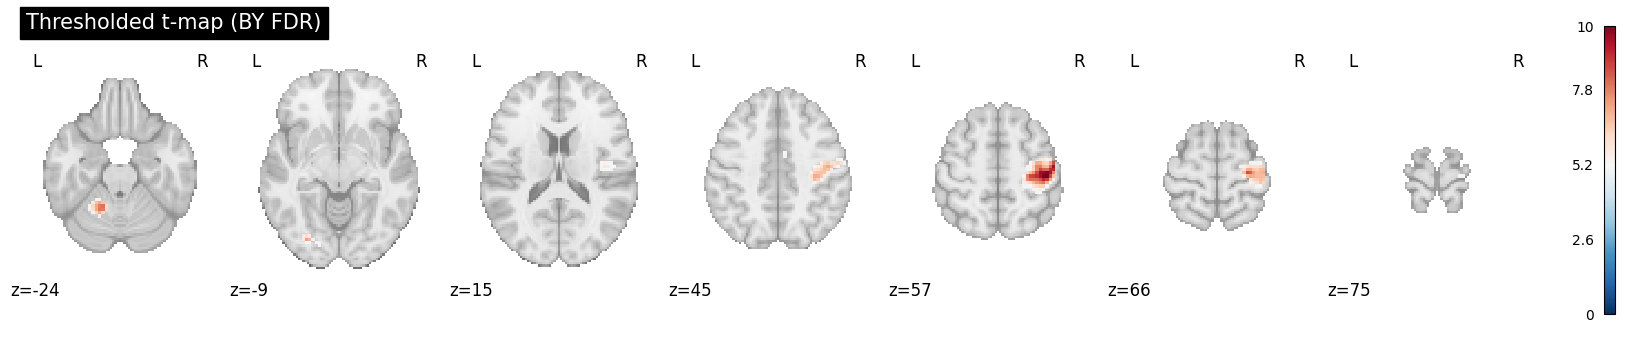

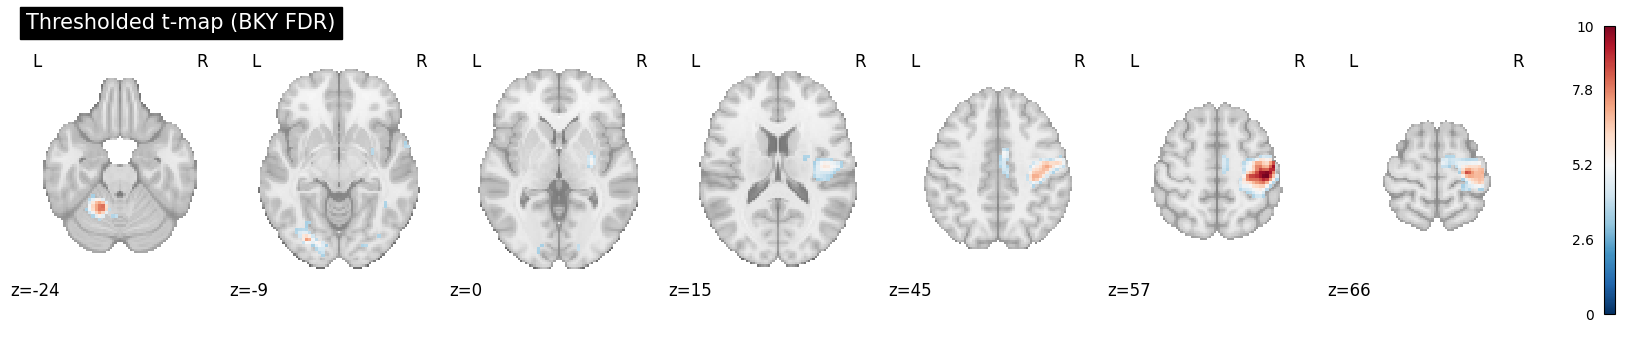

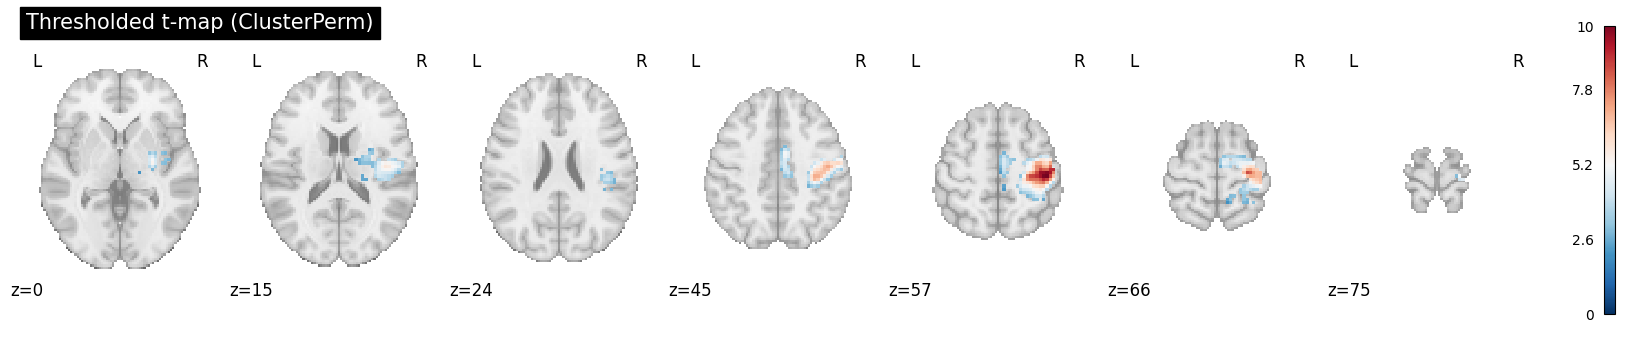

In [ ]:
#Tom said to save as Nifti- remember to use old headers
import numpy as np
import nibabel as nib
from nilearn import plotting

tdata = t_map.get_fdata()

def threshold_tmap(mask_bool, name, out_file):
    thr = np.zeros_like(tdata, dtype=np.float32)
    thr[mask_bool] = tdata[mask_bool]
    thr_img = nib.Nifti1Image(thr, affine=t_map.affine, header=t_map.header.copy()) #reusing old headers
    nib.save(thr_img, out_file) #saving as nifti

    plotting.plot_stat_map(
        thr_img,
        title=f"Thresholded t-map ({name})",
        display_mode="z",
        colorbar=True
    )
    return thr_img

t_unc_img  = threshold_tmap(unc,  "Uncorrected (p < 0.05)", "t_uncorrected.nii.gz")
t_bonf_img = threshold_tmap(bonf, "Bonferroni", "t_bonferroni.nii.gz")
t_bh_img   = threshold_tmap(bh,"BH FDR", "t_bh_fdr.nii.gz")
t_by_img   = threshold_tmap(by,"BY FDR","t_by_fdr.nii.gz")
t_bky_img  = threshold_tmap(bky,"BKY FDR","t_bky_fdr.nii.gz")
t_clus_img = threshold_tmap(clus,"ClusterPerm", "t_clus_perm.nii.gz")

plotting.show()

In [ ]:
from google.colab import files
files.download("t_clus_perm.nii.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>